In [1]:
import os
import pandas as pd
import numpy as np
import duckdb

start with looking at the head of all the smaller files but chartevents
generating the csvs for all the smaller files: d_items,icustays,patients and admissions

In [2]:
d_items_path='../data/d_items.csv.gz'
icustays_path='../data/icustays.csv.gz'
patients_path='../data/patients.csv.gz'
admissions_path='../data/admissions.csv.gz'
chartevents_path='../data/chartevents.csv.gz'
d_items=pd.read_csv(d_items_path)
icustays=pd.read_csv(icustays_path)
patients=pd.read_csv(patients_path)
admissions=pd.read_csv(admissions_path)
print("all the files have been converted to csvs")

all the files have been converted to csvs


In [3]:
d_items.head()

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220001,Problem List,Problem List,chartevents,General,NaN,Text,NaN,NaN
1,220003,ICU Admission date,ICU Admission date,datetimeevents,ADT,NaN,Date and time,NaN,NaN
2,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
3,220046,Heart rate Alarm - High,HR Alarm - High,chartevents,Alarms,bpm,Numeric,NaN,NaN
4,220047,Heart Rate Alarm - Low,HR Alarm - Low,chartevents,Alarms,bpm,Numeric,NaN,NaN


<h5>inferences: everything except item id, label and abbrev is pretty insignificant so just the first 3 is sufficient for now and check which is most linked to preferably its chartevents</h5>



In [4]:
patients.head()

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaN
2,10000058,F,33,2168,2020 - 2022,NaN
3,10000068,F,19,2160,2008 - 2010,NaN
4,10000084,M,72,2160,2017 - 2019,2161-02-13


<h5>inferences: subject id will be the only fruitful column in this table and will link to icustays.</h5>



In [5]:
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


<h5>as said above stay id is linked to subj id here but intime and outtime is pretty useful from here.</h5>



In [6]:
admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaN,URGENT,P49AFC,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,2180-05-06 19:17:00,2180-05-06 23:30:00,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaN,EW EMER.,P784FA,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-06-26 15:54:00,2180-06-26 21:31:00,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaN,EW EMER.,P19UTS,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,2180-08-05 20:58:00,2180-08-06 01:44:00,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaN,EW EMER.,P06OTX,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,2180-07-23 05:54:00,2180-07-23 14:00:00,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaN,EU OBSERVATION,P39NWO,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,2160-03-03 21:55:00,2160-03-04 06:26:00,0


<h5>inferences: not completely sure of the distinction between admittime, intime etc check doc and almost everything but the first few cols is redundant</h5>



In [7]:
# for chartevents alone:
chartevents_preview=pd.read_csv('../data/chartevents.csv.gz',nrows=5)

chartevents_preview.head()

,subject_id,hadm_id,stay_id,caregiver_id,charttime,storetime,itemid,value,valuenum,valueuom,warning
0,10000032,29079034,39553978,18704,2180-07-23 12:36:00,2180-07-23 14:45:00,226512,39.4,39.4,kg,0
1,10000032,29079034,39553978,18704,2180-07-23 12:36:00,2180-07-23 14:45:00,226707,60,60.0,Inch,0
2,10000032,29079034,39553978,18704,2180-07-23 12:36:00,2180-07-23 14:45:00,226730,152,152.0,cm,0
3,10000032,29079034,39553978,18704,2180-07-23 14:00:00,2180-07-23 14:18:00,220048,SR (Sinus Rhythm),NaN,NaN,0
4,10000032,29079034,39553978,18704,2180-07-23 14:00:00,2180-07-23 14:18:00,224642,Oral,NaN,NaN,0


<h4>most important one linking all of them, need to take batches of data based on the subject id and then cumulate all the values from the items</h4>
<h5> itemid from d_items must be subs here and grouping done by subject_id;</h5>



In [8]:
print("patients columns:",patients.columns.tolist())
print("icustays columns:",icustays.columns.tolist())
print("admissions columns:",admissions.columns.tolist())
print("d_items columns:",d_items.columns.tolist())
print("chartevents columns:",chartevents_preview.columns.tolist())

patients columns: ['subject_id', 'gender', 'anchor_age', 'anchor_year', 'anchor_year_group', 'dod']
icustays columns: ['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit', 'intime', 'outtime', 'los']
admissions columns: ['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
d_items columns: ['itemid', 'label', 'abbreviation', 'linksto', 'category', 'unitname', 'param_type', 'lownormalvalue', 'highnormalvalue']
chartevents columns: ['subject_id', 'hadm_id', 'stay_id', 'caregiver_id', 'charttime', 'storetime', 'itemid', 'value', 'valuenum', 'valueuom', 'warning']


In [9]:
#to create a a dictionary with most of the important vitals there are
print(d_items[d_items['label'].str.contains('heart rate', case=False, na=False)])
print("-------------------------------")
print(d_items[d_items['label'].str.contains('respiratory rate', case=False, na=False)])
print("-------------------------------")
print(d_items[d_items['label'].str.contains('systolic', case=False, na=False)])
print("-------------------------------")
print(d_items[d_items['label'].str.contains('temperature', case=False, na=False)])
print("-------------------------------")
print(d_items[d_items['label'].str.contains('diastolic', case=False, na=False)])
print("-------------------------------")
print(d_items[d_items['label'].str.contains('oxygen', case=False, na=False)])


   itemid                    label     abbreviation      linksto  \
2  220045               Heart Rate               HR  chartevents   
3  220046  Heart rate Alarm - High  HR Alarm - High  chartevents   
4  220047   Heart Rate Alarm - Low   HR Alarm - Low  chartevents   

              category unitname param_type  lownormalvalue  highnormalvalue  
2  Routine Vital Signs      bpm    Numeric             NaN              NaN  
3               Alarms      bpm    Numeric             NaN              NaN  
4               Alarms      bpm    Numeric             NaN              NaN  
-------------------------------
     itemid                           label                    abbreviation  \
28   220210                Respiratory Rate                              RR   
799  224688          Respiratory Rate (Set)          Respiratory Rate (Set)   
800  224689  Respiratory Rate (spontaneous)  Respiratory Rate (spontaneous)   
801  224690        Respiratory Rate (Total)        Respiratory Rate

In [10]:
#mapping dictionary for the vitals from d_items file:
vitals_dict={"spO2":220277,"temp(C)":223762,"temp(F)":223761,"heartrate":220045,"ARTsys":225309,"ARTdia":225310,"ARTmean":225312,"NBPs":220179,"NBPd":220180,"NBPm":220181,"RR":220210}
vitals,ids=list(vitals_dict.keys()),list(vitals_dict.values())
vitals_rev_dict={vitals_dict[i]:i for i in vitals_dict}
print(vitals,ids,vitals_rev_dict)

['spO2', 'temp(C)', 'temp(F)', 'heartrate', 'ARTsys', 'ARTdia', 'ARTmean', 'NBPs', 'NBPd', 'NBPm', 'RR'] [220277, 223762, 223761, 220045, 225309, 225310, 225312, 220179, 220180, 220181, 220210] {220277: 'spO2', 223762: 'temp(C)', 223761: 'temp(F)', 220045: 'heartrate', 225309: 'ARTsys', 225310: 'ARTdia', 225312: 'ARTmean', 220179: 'NBPs', 220180: 'NBPd', 220181: 'NBPm', 220210: 'RR'}


update: take the temperature in farenheit also cuz it will has more data than celcius and for the missing values in temp C, substitute with tempeaarture from Farenheit part ; new update : not adding glucose

In [11]:
con=duckdb.connect()

In [12]:
# result["vitals"] = result["itemid"].map(vitals_rev_dict)

# result

group the chartevent work by itemids instead and then map the respective vitals

thats the count of each vital present in the data frame so heartrate is obviously to be taken 

In [13]:
# WERE GETTING THE CHARTEVENTS DF FOR ONCE NOW TO CHECK ITS STATS AND THEN WE SHALL PIVOT IT

In [14]:
querychev=f"""
SELECT subject_id,stay_id,charttime,itemid,valuenum
FROM read_csv_auto('{chartevents_path}')
WHERE itemid in {ids}
"""
rawchev=con.execute(querychev).fetch_df()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
rawchev.head()

,subject_id,stay_id,charttime,itemid,valuenum
0,10000032,39553978,2180-07-23 14:00:00,223761,98.7
1,10000032,39553978,2180-07-23 14:11:00,220179,84.0
2,10000032,39553978,2180-07-23 14:11:00,220180,48.0
3,10000032,39553978,2180-07-23 14:11:00,220181,56.0
4,10000032,39553978,2180-07-23 14:12:00,220045,91.0


In [16]:
rawchev.shape

(45701186, 5)

In [17]:
rawchev["vitals"]=rawchev["itemid"].map(vitals_rev_dict)
rawchev.head()

,subject_id,stay_id,charttime,itemid,valuenum,vitals
0,10000032,39553978,2180-07-23 14:00:00,223761,98.7,temp(F)
1,10000032,39553978,2180-07-23 14:11:00,220179,84.0,NBPs
2,10000032,39553978,2180-07-23 14:11:00,220180,48.0,NBPd
3,10000032,39553978,2180-07-23 14:11:00,220181,56.0,NBPm
4,10000032,39553978,2180-07-23 14:12:00,220045,91.0,heartrate


In [18]:
pivoted = rawchev.pivot(values="valuenum",columns="vitals",index=["subject_id","stay_id","charttime"])
#df.pivot_table(values='v', index='a', columns='b', aggfunc='mean')

In [19]:
pivoted.head()

vitals                                   ARTdia  ARTmean  ARTsys  NBPd  NBPm  \
subject_id stay_id  charttime                                                  
10000032   39553978 2180-07-23 14:00:00     NaN      NaN     NaN   NaN   NaN   
                    2180-07-23 14:11:00     NaN      NaN     NaN  48.0  56.0   
                    2180-07-23 14:12:00     NaN      NaN     NaN   NaN   NaN   
                    2180-07-23 14:13:00     NaN      NaN     NaN   NaN   NaN   
                    2180-07-23 14:30:00     NaN      NaN     NaN  59.0  67.0   

vitals                                   NBPs    RR  heartrate  spO2  temp(C)  \
subject_id stay_id  charttime                                                   
10000032   39553978 2180-07-23 14:00:00   NaN   NaN        NaN   NaN      NaN   
                    2180-07-23 14:11:00  84.0   NaN        NaN   NaN      NaN   
                    2180-07-23 14:12:00   NaN  24.0       91.0   NaN      NaN   
                    2180-07-23 14:13:00   NaN   NaN        NaN  98.0      NaN   
                    2180-07-23 14:30:00  95.0  21.0       93.0  97.0      NaN   

vitals                                   temp(F)  
subject_id stay_id  charttime                     
10000032   39553978 2180-07-23 14:00:00     98.7  
                    2180-07-23 14:11:00      NaN  
                    2180-07-23 14:12:00      NaN  
                    2180-07-23 14:13:00      NaN  
                    2180-07-23 14:30:00      NaN

In [20]:
pivoted.isna().sum()


vitals
ARTdia       12138267
ARTmean      12135816
ARTsys       12138178
NBPd          7148469
NBPm          7153236
NBPs          7147418
RR            3889503
heartrate     3774089
spO2          3959143
temp(C)      12131315
temp(F)      10471118
dtype: int64

In [21]:
pivoted.isna().mean()*100

vitals
ARTdia       96.903352
ARTmean      96.883785
ARTsys       96.902642
NBPd         57.068329
NBPm         57.106385
NBPs         57.059938
RR           31.051045
heartrate    30.129661
spO2         31.607002
temp(C)      96.847852
temp(F)      83.594012
dtype: float64

In [22]:
icustays.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113


In [23]:
icustays.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los'],
      dtype='str')

In [24]:
icustays['intime']=pd.to_datetime(icustays['intime'])
icustays['outtime']=pd.to_datetime(icustays['outtime'])
icustays["stayhours"]=(icustays['outtime']-icustays['intime']).dt.total_seconds()/3600
icustays.head()
icustays["stayhours"].describe()
#take icu stays here cuz we need those entries who have a tangible amount of time spent under supervision which is atleast 4 hrs

count    94444.000000
mean        87.120596
std        129.659365
min          0.030000
25%         26.309097
50%         47.175556
75%         92.701806
max       5433.673889
Name: stayhours, dtype: float64

In [25]:
icustayswmorethan4 = icustays[icustays["stayhours"] >= 4].copy()
icustayswmorethan4.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,stayhours
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,9.846389
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,93.438056
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,11.940833
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,26.832778
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,22.754722


In [26]:
icustayswmorethan4.describe()

,subject_id,hadm_id,stay_id,intime,outtime,los,stayhours
count,9.373000e+04,9.373000e+04,9.373000e+04,93730,93730,93730.000000,93730.000000
mean,1.500421e+07,2.498339e+07,3.499724e+07,2153-10-26 00:51:53.396363,2153-10-29 16:37:56.498602,3.656980,87.767528
min,1.000003e+07,2.000009e+07,3.000015e+07,2110-01-11 10:16:06,2110-01-12 17:17:47,0.167095,4.010278
25%,1.251681e+07,2.248571e+07,3.250626e+07,2133-11-22 11:13:52.250000,2133-11-25 23:51:13.500000,1.108180,26.596319
50%,1.500336e+07,2.498502e+07,3.499794e+07,2153-09-30 08:03:48,2153-10-02 22:22:54,1.978628,47.487083
75%,1.751767e+07,2.746640e+07,3.748965e+07,2173-11-23 08:39:30,2173-11-27 14:39:08.250000,3.885909,93.261806
max,1.999999e+07,2.999983e+07,3.999986e+07,2214-07-22 17:05:53,2214-07-26 17:13:57,226.403079,5433.673889
std,2.884018e+06,2.883499e+06,2.886190e+06,NaN,NaN,5.414142,129.939397


In [27]:
stayids=icustayswmorethan4["stay_id"]
len(stayids)
# this is the list of stay ids which have more than 4 hrs of stay time so well filter jjust this form the entire dataset

93730

In [28]:
pivoted.columns
pivoted = pivoted.reset_index()
pivoted.columns
#always reset indices before manipulating and then set the index later. columns and indices go speraetly in terms of fn calls

Index(['subject_id', 'stay_id', 'charttime', 'ARTdia', 'ARTmean', 'ARTsys',
       'NBPd', 'NBPm', 'NBPs', 'RR', 'heartrate', 'spO2', 'temp(C)',
       'temp(F)'],
      dtype='str', name='vitals')

In [29]:
pivoted=pivoted[pivoted["stay_id"].isin(stayids)].copy()
pivoted.head()
#now get just the stay ids who have more than 4 hrs

vitals,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F)
0,10000032,39553978,2180-07-23 14:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.7
1,10000032,39553978,2180-07-23 14:11:00,NaN,NaN,NaN,48.0,56.0,84.0,NaN,NaN,NaN,NaN,NaN
2,10000032,39553978,2180-07-23 14:12:00,NaN,NaN,NaN,NaN,NaN,NaN,24.0,91.0,NaN,NaN,NaN
3,10000032,39553978,2180-07-23 14:13:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.0,NaN,NaN
4,10000032,39553978,2180-07-23 14:30:00,NaN,NaN,NaN,59.0,67.0,95.0,21.0,93.0,97.0,NaN,NaN


In [30]:
df=pivoted.sort_values(["stay_id","charttime"]).reset_index(drop=True)
df.head()

vitals,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F)
0,12466550,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN
1,12466550,30000153,2174-09-29 12:06:00,NaN,NaN,NaN,74.0,89.0,136.0,NaN,100.0,NaN,NaN,NaN
2,12466550,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8
3,12466550,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN
4,12466550,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN


In [31]:
exid=df["stay_id"].iloc[0]
examplestay=df[df["stay_id"]==exid].copy()
examplestay.head()
#looking at one stay for now , avoidable 

vitals,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F)
0,12466550,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN
1,12466550,30000153,2174-09-29 12:06:00,NaN,NaN,NaN,74.0,89.0,136.0,NaN,100.0,NaN,NaN,NaN
2,12466550,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8
3,12466550,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN
4,12466550,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN


In [32]:
examplestay["timegap"]=examplestay["charttime"].diff()
examplestay.head()

vitals,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),timegap
0,12466550,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaT
1,12466550,30000153,2174-09-29 12:06:00,NaN,NaN,NaN,74.0,89.0,136.0,NaN,100.0,NaN,NaN,NaN,0 days 00:01:00
2,12466550,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8,0 days 00:02:00
3,12466550,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN,0 days 00:01:00
4,12466550,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN,0 days 00:51:00


In [33]:
df["time_diff"]=df.groupby("stay_id")["charttime"].diff()
df.head()

vitals,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
0,12466550,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaT
1,12466550,30000153,2174-09-29 12:06:00,NaN,NaN,NaN,74.0,89.0,136.0,NaN,100.0,NaN,NaN,NaN,0 days 00:01:00
2,12466550,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8,0 days 00:02:00
3,12466550,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN,0 days 00:01:00
4,12466550,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN,0 days 00:51:00


In [34]:
df["time_diff"].describe()

count                  12423804
mean     0 days 00:39:17.572699
std      0 days 04:29:03.931292
min             0 days 00:01:00
25%             0 days 00:04:00
50%             0 days 00:58:00
75%             0 days 01:00:00
max           365 days 00:04:00
Name: time_diff, dtype: object

In [35]:
df.loc[df["time_diff"].nlargest(10).index,
    ["subject_id", "stay_id", "charttime", "time_diff"]
]

vitals,subject_id,stay_id,charttime,time_diff
6045809,18138079,34773087,2181-01-02 23:39:00,365 days 00:04:00
760853,16661755,30586760,2175-06-11 20:00:00,364 days 14:59:00
2927690,18536004,32321831,2214-05-23 23:00:00,362 days 08:30:00
8230151,10253349,36520389,2190-03-11 14:02:00,80 days 23:02:00
4637304,10636904,33659679,2112-04-23 19:00:00,66 days 00:00:00
5216546,16186431,34123444,2140-10-12 03:26:00,32 days 06:25:00
983050,11742905,30773051,2111-01-26 02:42:00,30 days 02:42:00
9986238,19611909,37946973,2160-11-20 23:25:00,30 days 00:00:00
11913524,18744840,39510663,2114-11-08 13:00:00,25 days 17:00:00
378990,19157548,30290852,2128-06-11 18:00:00,24 days 19:58:00


we see the same 2 subject ids having an exorbitant gap but is later removed.

In [12]:
vital_cols=[
    "ARTdia", "ARTmean", "ARTsys",
    "NBPd", "NBPm", "NBPs",
    "RR", "heartrate", "spO2", "temp(C)","temp(F)"
]

In [37]:
df_check=df.merge(icustays[["stay_id","intime","outtime"]], on="stay_id",how='left')
#pd.merge(df1, df2, on='key', how='inner') its an sql type inner join
df_check.head()

,subject_id,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff,intime,outtime
0,12466550,30000153,2174-09-29 12:05:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN,NaT,2174-09-29 12:09:00,2174-10-01 03:26:10
1,12466550,30000153,2174-09-29 12:06:00,NaN,NaN,NaN,74.0,89.0,136.0,NaN,100.0,NaN,NaN,NaN,0 days 00:01:00,2174-09-29 12:09:00,2174-10-01 03:26:10
2,12466550,30000153,2174-09-29 12:08:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,96.8,0 days 00:02:00,2174-09-29 12:09:00,2174-10-01 03:26:10
3,12466550,30000153,2174-09-29 12:09:00,NaN,NaN,NaN,NaN,NaN,NaN,18.0,NaN,NaN,NaN,NaN,0 days 00:01:00,2174-09-29 12:09:00,2174-10-01 03:26:10
4,12466550,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN,0 days 00:51:00,2174-09-29 12:09:00,2174-10-01 03:26:10


In [38]:
timethres=pd.Timedelta(hours=60)
diffthres=pd.Timedelta(days=1)
df_timeclean=df_check[
    (df_check["charttime"]>=df_check["intime"]-timethres)
      & 
    (df_check["charttime"]<=df_check["outtime"]+timethres)
     & 
    ((df_check["time_diff"].isna()))
      | 
    (df_check["time_diff"]<=diffthres)
    ].copy()
#setup a time threshold, we need only those entries which fall well within the intime and outttime bracket and the difference must be less than the setup thresholds.

In [39]:
uniform=(
    df_timeclean.set_index("charttime")
      .groupby("stay_id")[vital_cols]
      .resample("20min")
      .mean()
      .reset_index()
)
#resampling the dataset to 20 minute intervals as 5 mins didnt work well (NaN)

In [40]:
uniform.head()

,stay_id,charttime,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F)
0,30000153,2174-09-29 12:00:00,NaN,NaN,NaN,74.0,89.0,136.0,18.0,100.0,100.0,NaN,96.8
1,30000153,2174-09-29 12:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30000153,2174-09-29 12:40:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,30000153,2174-09-29 13:00:00,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN
4,30000153,2174-09-29 13:20:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
uniform=uniform.sort_values(["stay_id", "charttime"])
uniform=uniform.set_index("charttime")

In [42]:
uniform.head()

,stay_id,ARTdia,ARTmean,ARTsys,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F)
charttime,,,,,,,,,,,,
2174-09-29 12:00:00,30000153,NaN,NaN,NaN,74.0,89.0,136.0,18.0,100.0,100.0,NaN,96.8
2174-09-29 12:20:00,30000153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2174-09-29 12:40:00,30000153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2174-09-29 13:00:00,30000153,NaN,NaN,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN
2174-09-29 13:20:00,30000153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
uniform.groupby("stay_id").size().sort_values(ascending=False).head(10)

stay_id
36032605    16297
36307509    11493
39510663    10078
30359303     9790
31492392     9159
35629939     8731
39245279     8065
32380519     7439
38018615     7315
31879957     7169
dtype: int64

we get an abnormal reading spanning 1 year so it got split into 106830 samples of 5 minutes

In [44]:
uniform = uniform.reset_index()

uniform["time_diff"] = (
    uniform.groupby("stay_id")["charttime"].diff()
)

uniform = uniform.set_index("charttime")

In [45]:
uniform["time_diff"].describe()

count           24204470
mean     0 days 00:20:00
std      0 days 00:00:00
min      0 days 00:20:00
25%      0 days 00:20:00
50%      0 days 00:20:00
75%      0 days 00:20:00
max      0 days 00:20:00
Name: time_diff, dtype: object

FINALLY all of the data has been made into workable time series data of 20* mins intervals after removing the stray huge interval samples

In [46]:

(uniform.isna().mean() * 100).sort_values(ascending=False)

ARTdia       98.528969
ARTsys       98.528665
ARTmean      98.520812
temp(C)      98.467092
temp(F)      91.596138
NBPm         78.477508
NBPd         78.463758
NBPs         78.459926
spO2         66.402135
RR           66.210944
heartrate    65.815219
time_diff     0.385745
stay_id       0.000000
dtype: float64

In [47]:
for i in vital_cols:
    actual = uniform[uniform[i].notna()].copy()

    actual["gap"] = (actual.index.to_series().groupby(actual["stay_id"]).diff())
    print(f"\n{i}")
    print(actual["gap"].dropna().describe())
    #find the time gap between 2 successive readings in each of these vitals. and then we can restrucutre it.


ARTdia
count                    350480
mean     0 days 01:06:07.724263
std      0 days 06:45:50.078119
min             0 days 00:20:00
25%             0 days 01:00:00
50%             0 days 01:00:00
75%             0 days 01:00:00
max            73 days 16:20:00
Name: gap, dtype: object

ARTmean
count                    352339
mean     0 days 01:06:35.349932
std      0 days 06:55:23.222860
min             0 days 00:20:00
25%             0 days 01:00:00
50%             0 days 01:00:00
75%             0 days 01:00:00
max            73 days 16:20:00
Name: gap, dtype: object

ARTsys
count                    350532
mean     0 days 01:06:24.896100
std      0 days 06:56:25.747798
min             0 days 00:20:00
25%             0 days 01:00:00
50%             0 days 01:00:00
75%             0 days 01:00:00
max            73 days 16:20:00
Name: gap, dtype: object

NBPd
count                   5140390
mean     0 days 01:23:53.791755
std      0 days 06:25:20.582964
min             0 days 00:20:0

so for: spo2: avg is 57 mins, temp is 1hr 19 mins, heart rate is 56mins art sys and dia (and hence mean) is 1 hr 2 mins nbps nbpd and nbpm is 1hr 21 mins rr is 55 mins so take the avrage around 1.5 hrs

In [48]:
uniform.shape

(24298199, 13)

In [49]:
uniform.memory_usage(deep=True).sum() / 1024**3
#space occupied by uniform ~ 2gigs

np.float64(2.5344996601343155)

In [50]:
for col in vital_cols:
    uniform[col] = uniform.groupby("stay_id")[col].ffill(limit=4)

In [51]:
uniform[vital_cols].isna().sum()

ARTdia       23296127
ARTmean      23290960
ARTsys       23295929
NBPd          8673193
NBPm          8688088
NBPs          8671285
RR             839023
heartrate      598904
spO2           893415
temp(C)      23159285
temp(F)      14601607
dtype: int64

In [52]:
uniform[vital_cols].isna().sum()

ARTdia       23296127
ARTmean      23290960
ARTsys       23295929
NBPd          8673193
NBPm          8688088
NBPs          8671285
RR             839023
heartrate      598904
spO2           893415
temp(C)      23159285
temp(F)      14601607
dtype: int64

In [53]:
(uniform[vital_cols].isna().mean() * 100).sort_values(ascending=False)
#artdia and sys have extremely high amount of Nans

ARTdia       95.875941
ARTsys       95.875126
ARTmean      95.854676
temp(C)      95.312764
temp(F)      60.093372
NBPm         35.756099
NBPd         35.694798
NBPs         35.686945
spO2          3.676877
RR            3.453025
heartrate     2.464808
dtype: float64

In [54]:
uniform = uniform.drop(columns=["ARTdia","ARTsys"])
uniform.head()

,stay_id,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
charttime,,,,,,,,,,,
2174-09-29 12:00:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,NaN,96.8,NaT
2174-09-29 12:20:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,NaN,96.8,0 days 00:20:00
2174-09-29 12:40:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,NaN,96.8,0 days 00:20:00
2174-09-29 13:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,96.8,0 days 00:20:00
2174-09-29 13:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,96.8,0 days 00:20:00


In [55]:
# d_items[d_items["label"].str.contains(
#     "glucose|fio2|oxygen|gcs|pain|urine|respiratory|ventilator",
#     case=False,
#     na=False
# )][["itemid", "label"]].head(20)

In [56]:
temp_f_converted = (uniform["temp(F)"] - 32) * 5 / 9
uniform["temp(C)"] = uniform["temp(C)"].combine_first(temp_f_converted)

In [10]:
uniform=pd.read_parquet("uniform_20min.parquet")
vitals_new=uniform.columns
vitals_new

Index(['stay_id', 'ARTmean', 'NBPd', 'NBPm', 'NBPs', 'RR', 'heartrate', 'spO2',
       'temp(C)', 'temp(F)', 'time_diff'],
      dtype='str')

In [58]:
(uniform[vitals_new].isna().mean() * 100).sort_values(ascending=False)

ARTmean      95.854676
temp(F)      60.093372
temp(C)      55.533396
NBPm         35.756099
NBPd         35.694798
NBPs         35.686945
spO2          3.676877
RR            3.453025
heartrate     2.464808
time_diff     0.385745
stay_id       0.000000
dtype: float64

In [59]:
uniform.sort_values(['stay_id','charttime'])
uniform.head(10)
#df.sort_values('a', ascending=False)

,stay_id,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
charttime,,,,,,,,,,,
2174-09-29 12:00:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,NaT
2174-09-29 12:20:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,0 days 00:20:00
2174-09-29 12:40:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,0 days 00:20:00
2174-09-29 13:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,96.8,0 days 00:20:00
2174-09-29 13:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,96.8,0 days 00:20:00
2174-09-29 13:40:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN,0 days 00:20:00
2174-09-29 14:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,37.277778,99.1,0 days 00:20:00
2174-09-29 14:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,37.277778,99.1,0 days 00:20:00
2174-09-29 14:40:00,30000153,NaN,NaN,NaN,NaN,16.0,83.0,100.0,37.277778,99.1,0 days 00:20:00


In [60]:
import pandas as pd
import pyarrow as pa

print(pd.__version__)
print(pa.__version__)

3.0.5
25.0.1


In [61]:
import pyarrow
uniform.to_parquet("uniform_20min.parquet")


Parquet is basically a data file format designed for big datasets. 
Think of it as a much smarter alternative to CSV.

In [62]:
import os
os.path.getsize("uniform_20min.parquet") / 1024**3
#occupies much less space.

0.2557705994695425

# THIS IS THE CHECKPOINT FOR RECOVERING THE UNIFORM DATAFRAME WHICH WAS SAVED AS A PARQUET. RUN THIS LINE FOR IMPLMENTATIONS HENCE FORTH

In [63]:
import os
import pandas as pd
import numpy as np
import duckdb

In [64]:
d_items_path='../data/d_items.csv.gz'
icustays_path='../data/icustays.csv.gz'
patients_path='../data/patients.csv.gz'
admissions_path='../data/admissions.csv.gz'
chartevents_path='../data/chartevents.csv.gz'
d_items=pd.read_csv(d_items_path)
icustays=pd.read_csv(icustays_path)
patients=pd.read_csv(patients_path)
admissions=pd.read_csv(admissions_path)
print("all the files have been converted to csvs")

all the files have been converted to csvs


In [65]:
uniform = pd.read_parquet("uniform_20min.parquet")

In [66]:
uniform.head()

,stay_id,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
charttime,,,,,,,,,,,
2174-09-29 12:00:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT
2174-09-29 12:20:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
2174-09-29 12:40:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
2174-09-29 13:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00
2174-09-29 13:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00


In [67]:
#optional
print(uniform.index.name)
print(uniform.columns)

charttime
Index(['stay_id', 'ARTmean', 'NBPd', 'NBPm', 'NBPs', 'RR', 'heartrate', 'spO2',
       'temp(C)', 'temp(F)', 'time_diff'],
      dtype='str')


In [68]:
#optional
diffs = (
    uniform.groupby("stay_id", sort=False)
    .apply(lambda x: x.index.to_series().diff())
    .dropna()
)
#check the spacing thruout
diffs.value_counts().head()

charttime
0 days 00:20:00    24204470
Name: count, dtype: int64

In [69]:
uniform = uniform.sort_values(["stay_id", uniform.index.name])

In [70]:
#taking 2 hr windows now
window_size = 6
uniform["window_id"]=(uniform.groupby("stay_id")).cumcount()//window_size
uniform.head(10)


,stay_id,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff,window_id
charttime,,,,,,,,,,,,
2174-09-29 12:00:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,NaT,0
2174-09-29 12:20:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,0 days 00:20:00,0
2174-09-29 12:40:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,96.8,0 days 00:20:00,0
2174-09-29 13:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,96.8,0 days 00:20:00,0
2174-09-29 13:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,96.8,0 days 00:20:00,0
2174-09-29 13:40:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,NaN,NaN,0 days 00:20:00,0
2174-09-29 14:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,37.277778,99.1,0 days 00:20:00,1
2174-09-29 14:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,37.277778,99.1,0 days 00:20:00,1
2174-09-29 14:40:00,30000153,NaN,NaN,NaN,NaN,16.0,83.0,100.0,37.277778,99.1,0 days 00:20:00,1


In [71]:
#optional
uniform.columns

Index(['stay_id', 'ARTmean', 'NBPd', 'NBPm', 'NBPs', 'RR', 'heartrate', 'spO2',
       'temp(C)', 'temp(F)', 'time_diff', 'window_id'],
      dtype='str')

In [72]:
vitalsnew=[
    "ARTmean",
    "NBPd", "NBPm", "NBPs",
    "RR", "heartrate", "spO2", "temp(C)"
]

In [73]:
completeness = (
    uniform[vitalsnew].notna()
    .groupby([uniform["stay_id"], uniform["window_id"]])
    .mean()
)

In [74]:
#optional
completeness.head()

ARTmean      NBPd      NBPm      NBPs   RR  heartrate  \
stay_id  window_id                                                          
30000153 0              0.0  1.000000  1.000000  1.000000  1.0        1.0   
         1              0.0  0.333333  0.333333  0.333333  1.0        1.0   
         2              0.0  0.000000  0.000000  0.000000  1.0        1.0   
         3              0.0  0.000000  0.000000  0.000000  1.0        1.0   
         4              0.0  0.000000  0.000000  0.000000  1.0        1.0   

                    spO2   temp(C)  
stay_id  window_id                  
30000153 0           1.0  0.833333  
         1           1.0  0.833333  
         2           1.0  0.833333  
         3           1.0  0.000000  
         4           1.0  0.833333

In [75]:
#optional
completeness.describe()

,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C)
count,4.091355e+06,4.091355e+06,4.091355e+06,4.091355e+06,4.091355e+06,4.091355e+06,4.091355e+06,4.091355e+06
mean,4.115466e-02,6.451327e-01,6.444714e-01,6.452126e-01,9.653385e-01,9.752816e-01,9.628208e-01,4.443734e-01
std,1.969670e-01,4.565646e-01,4.570232e-01,4.565400e-01,1.588079e-01,1.283132e-01,1.598789e-01,3.341589e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.666667e-01
50%,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e-01
75%,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,8.333333e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [76]:
morethanthresrows=completeness[completeness[["RR","heartrate","spO2"]]>=0.8].all(axis=1)
morethanthresrows.head()
stayidsmorethanthres=morethanthresrows.index.get_level_values("stay_id").unique()
stayidsmorethanthres

Index([30000153, 30000213, 30000484, 30000646, 30000831, 30001148, 30001336,
       30001396, 30001446, 30001471,
       ...
       39999168, 39999172, 39999230, 39999286, 39999301, 39999384, 39999552,
       39999562, 39999810, 39999858],
      dtype='int64', name='stay_id', length=93729)

In [77]:
uniform_reset = uniform.reset_index() 
uniform_reset.head()

,charttime,stay_id,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff,window_id
0,2174-09-29 12:00:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT,0
1,2174-09-29 12:20:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,0
2,2174-09-29 12:40:00,30000153,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,0
3,2174-09-29 13:00:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,0
4,2174-09-29 13:20:00,30000153,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,0


In [78]:
 # charttime becomes a normal column now
uniform_filtered = uniform_reset.set_index(["stay_id","window_id"]).loc[morethanthresrows.index].reset_index()
uniform_filtered.head()

,stay_id,window_id,charttime,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
0,30000153,0,2174-09-29 12:00:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT
1,30000153,0,2174-09-29 12:20:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
2,30000153,0,2174-09-29 12:40:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
3,30000153,0,2174-09-29 13:00:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00
4,30000153,0,2174-09-29 13:20:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00


taking only the rows which pass that threshold, then removing that index and then setting backt he index

In [79]:
#optional
uniform_filtered.columns

Index(['stay_id', 'window_id', 'charttime', 'ARTmean', 'NBPd', 'NBPm', 'NBPs',
       'RR', 'heartrate', 'spO2', 'temp(C)', 'temp(F)', 'time_diff'],
      dtype='str')

In [80]:
#optional
uniform_filtered.head()

,stay_id,window_id,charttime,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff
0,30000153,0,2174-09-29 12:00:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT
1,30000153,0,2174-09-29 12:20:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
2,30000153,0,2174-09-29 12:40:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00
3,30000153,0,2174-09-29 13:00:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00
4,30000153,0,2174-09-29 13:20:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00


In [81]:
uniform_filtered.drop(columns=["temp(F)"])

,stay_id,window_id,charttime,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),time_diff
0,30000153,0,2174-09-29 12:00:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,NaT
1,30000153,0,2174-09-29 12:20:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,0 days 00:20:00
2,30000153,0,2174-09-29 12:40:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.000000,0 days 00:20:00
3,30000153,0,2174-09-29 13:00:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,0 days 00:20:00
4,30000153,0,2174-09-29 13:20:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.000000,0 days 00:20:00
...,...,...,...,...,...,...,...,...,...,...,...,...
24298194,39999858,44,2167-04-30 06:40:00,NaN,NaN,NaN,NaN,27.0,68.0,94.0,NaN,0 days 00:20:00
24298195,39999858,45,2167-04-30 07:00:00,NaN,NaN,NaN,NaN,26.0,96.0,88.0,NaN,0 days 00:20:00
24298196,39999858,45,2167-04-30 07:20:00,NaN,NaN,NaN,NaN,26.0,96.0,88.0,NaN,0 days 00:20:00
24298197,39999858,45,2167-04-30 07:40:00,NaN,NaN,NaN,NaN,26.0,96.0,88.0,NaN,0 days 00:20:00


In [82]:
uniform_filtered["window_uid"]=(uniform_filtered["stay_id"].astype(str)+"_"+uniform_filtered["window_id"].astype(str))
uniform_filtered.head()

,stay_id,window_id,charttime,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff,window_uid
0,30000153,0,2174-09-29 12:00:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT,30000153_0
1,30000153,0,2174-09-29 12:20:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
2,30000153,0,2174-09-29 12:40:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
3,30000153,0,2174-09-29 13:00:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
4,30000153,0,2174-09-29 13:20:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0


In [3]:
uniform_filtered.to_parquet("uniform_filtered.parquet")

NameError: name 'uniform_filtered' is not defined

In [16]:
vitals1 = ["heartrate", "spO2", "RR", "NBPd", "NBPm", "NBPs", "ARTmean", "temp(C)"]

In [85]:
long_df=uniform_filtered.melt(id_vars=["window_uid","charttime"],value_vars=vitals1,var_name="vital",value_name="reading").dropna(subset=["reading"])
#df.melt(id_vars=['a'], value_vars=['b','c'])

In [86]:
long_df.to_parquet("long_df_full.parquet")
#please use the parquet henceforth

In [87]:
long_df.head()

,window_uid,charttime,vital,reading
0,30000153_0,2174-09-29 12:00:00,heartrate,100.0
1,30000153_0,2174-09-29 12:20:00,heartrate,100.0
2,30000153_0,2174-09-29 12:40:00,heartrate,100.0
3,30000153_0,2174-09-29 13:00:00,heartrate,104.0
4,30000153_0,2174-09-29 13:20:00,heartrate,104.0


#### YOU CAN TAKE THE LONG DF PARQUET INSTEAD NO NEED OF THE UNIFORM PARQUET PART

next is the tsfresh part - tsfresh (Time Series Feature extraction based on scalable hypothesis tests) is a library which extracts distinct features from time series data.

In [3]:
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters
from tsfresh.utilities.dataframe_functions import impute
import pandas as pd
import numpy as np

In [4]:
import numpy as np
import pandas as pd
import gc
from tsfresh import extract_features
from tsfresh.feature_extraction import EfficientFCParameters

fc_parameters = EfficientFCParameters()
fc_parameters.pop("binned_entropy", None)

[{'max_bins': 10}]

When we use EfficientFCParameters(), tsfresh runs about 70-90 math formulas on every window. Here are the three main types of "facts" it figures out:
Distribution Facts: What is the mean, median, max, min, and standard deviation? (Standard stuff).
Temporal Facts (Time-based):
Linear Trend: What is the slope of the line? (Is the patient getting worse or better?)
Absolute Energy: How much "power" is in the signal?
Complexity: Is the signal "noisy" and jumping around, or is it smooth?
Position Facts: At what point in the 2 hours did the maximum heart rate occur? Was it at the beginning or the end?
The result: It turns your 6 rows of "Raw Data" into one single row of "Mathematical Summary."

When you run `tsfresh` with `EfficientFCParameters()`, you are essentially asking the computer to describe your 2-hour ICU windows using math instead of raw numbers. 

Here is the breakdown of the "facts" it calculates for every vital sign in every window:

### 1. Distribution Facts (The "Spread")
These describe the general range and center of the data. 
*   **Mean & Median:** The average and middle values.
*   **Max & Min:** The extremes of the 2-hour window.
*   **Standard Deviation:** How much the vital sign "bounces" around the average.
*   **Skewness:** Is the data balanced, or are there "outlier" spikes in one direction?

### 2. Temporal Facts (The "Story" of the Signal)
These look at how the vital sign changes over time. This is where the **ECE (Signal Processing)** logic comes in.
*   **Linear Trend:** What is the slope of the line? (e.g., Is the heart rate steadily climbing or dropping?)
*   **Absolute Energy:** A measure of the total "power" or magnitude of the signal over those 2 hours.
*   **Complexity (Complexity Invariant Distance):** Is the signal "noisy" and jumping around erratically, or is it a smooth, predictable line?

### 3. Position Facts (The "Timing")
These tell you *when* things happened within the 2-hour window.
*   **Location of Max/Min:** Did the patient's heart rate peak at the very beginning of the window or at the very end? 
*   **Longest Strike:** Does the signal stay above or below its mean for a long time, or does it cross the average frequently?

---

### The Result: Dimensionality Reduction
The most important thing to understand is the **transformation**:

*   **Before `tsfresh`:** You have **6 rows** of raw measurements per window. A Machine Learning model can't easily "read" 6 rows at once to make a prediction.
*   **After `tsfresh`:** You have **1 single row** containing ~70 mathematical summaries. 

**It turns a "movie" (the 2-hour window) into a "still photo" (the feature summary) that a Machine Learning model can actually understand.**

---

**Wait, what happens next?**
Once you have this "still photo" (the `features_df`), you can feed it into an Anomaly Detection algorithm (like an Isolation Forest or an Autoencoder) to find the windows that look "weird" compared to the rest of the ICU stays.

**Ready to see how many windows you're about to process?** (Run `len(long_df)` to check the scale!)

In [3]:
settings = EfficientFCParameters()

In [ ]:
long_df=pd.read_parquet("long_df_full.parquet")
#the final cleaned dataset

In [ ]:
# import pycatch22

# def get_catch22_features(uniform_filtered, vital_cols):
#     results = []
#     for uid, group in uniform_filtered.groupby("window_uid"):
#         row = {"window_uid": uid}
#         for v in vital_cols:
#             vals = group[v].dropna().tolist()
#             if len(vals) >= 4:  # catch22 needs a minimum series length
#                 feats = pycatch22.catch22_all(vals)
#                 for name, val in zip(feats["names"], feats["values"]):
#                     row[f"{v}_{name}"] = val
#         results.append(row)
#     return pd.DataFrame(results).set_index("window_uid")

In [7]:
uniform_filtered=pd.read_parquet('uniform_filtered.parquet')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
import joblib

vital_cols = ["heartrate", "spO2", "RR", "NBPd", "NBPm", "NBPs", "ARTmean", "temp(C)"]

grouped = uniform_filtered.groupby("window_uid")[vital_cols]

feats = grouped.agg(['mean', 'std', 'min', 'max'])
feats.columns = ['_'.join(col) for col in feats.columns]

for v in vital_cols:
    feats[f"{v}_range"] = feats[f"{v}_max"] - feats[f"{v}_min"]

feats = feats.fillna(0) #impute
feats.to_parquet("features_final.parquet")

scaler = StandardScaler()
scaled = scaler.fit_transform(feats)

model = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
labels = model.fit_predict(scaled)
scores = model.decision_function(scaled)

results = pd.DataFrame({
    "window_uid": feats.index, "label": labels, "score": scores
}).sort_values("score")

results.to_parquet("results_final.parquet")
joblib.dump(model, "isoforest_model.joblib")
joblib.dump(scaler, "scaler.joblib")

print(results.head(10))

          window_uid  label     score
2014115   34882006_2     -1 -0.230544
2047127   34962562_1     -1 -0.204134
601155   31460673_49     -1 -0.203369
220858   30515444_53     -1 -0.202872
672749    31627753_3     -1 -0.201136
385878    30925163_0     -1 -0.199377
9424      30024511_3     -1 -0.198958
1003500  32428330_12     -1 -0.198435
1661166   34020415_1     -1 -0.197365
3248147   37913784_4     -1 -0.195383


In [5]:
uniform_filtered.head()

,stay_id,window_id,charttime,ARTmean,NBPd,NBPm,NBPs,RR,heartrate,spO2,temp(C),temp(F),time_diff,window_uid
0,30000153,0,2174-09-29 12:00:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,NaT,30000153_0
1,30000153,0,2174-09-29 12:20:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
2,30000153,0,2174-09-29 12:40:00,NaN,74.0,89.0,136.0,18.0,100.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
3,30000153,0,2174-09-29 13:00:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0
4,30000153,0,2174-09-29 13:20:00,NaN,77.0,84.0,113.0,16.0,104.0,100.0,36.0,96.8,0 days 00:20:00,30000153_0


In [ ]:
top_uids = [
    "34882006_2", "34962562_1", "31460673_49", "30515444_53",
    "31627753_3", "30925163_0", "30024511_3", "32428330_12",
    "34020415_1", "37913784_4"
]

In [ ]:
for i in top_uids:
    window_data = uniform_filtered[uniform_filtered["window_uid"] == i][
    ["charttime"] + vital_cols
    ]
    print(window_data)
    print(window_data[vital_cols].describe())
    print("---------------------------------------")

                   charttime  heartrate   spO2    RR   NBPd   NBPm   NBPs  \
11962965 2169-05-21 05:20:00      138.0  100.0  11.0  109.0  118.0  143.0   
11962966 2169-05-21 05:40:00      138.0  100.0  11.0  109.0  118.0  143.0   
11962967 2169-05-21 06:00:00      124.0   65.0  34.0   39.0   45.0   63.0   
11962968 2169-05-21 06:20:00      124.0   65.0  34.0   39.0   45.0   63.0   
11962969 2169-05-21 06:40:00      124.0   65.0  34.0   39.0   45.0   63.0   
11962970 2169-05-21 07:00:00      155.0   44.0   0.0   98.0  113.0  159.0   

          ARTmean  temp(C)  
11962965     75.0      NaN  
11962966     75.0      NaN  
11962967     79.0      NaN  
11962968     79.0      NaN  
11962969     79.0      NaN  
11962970    173.0      NaN  
        heartrate        spO2         RR        NBPd        NBPm        NBPs  \
count    6.000000    6.000000   6.000000    6.000000    6.000000    6.000000   
mean   133.833333   73.166667  20.666667   72.166667   80.666667  105.666667   
std     12.432484

In [ ]:
baselines = uniform_filtered.groupby("stay_id").apply(lambda g: g[g["charttime"] < g["charttime"].min() + pd.Timedelta(hours=2)][vital_cols].agg(['mean', 'std']))

So turns out feature extraction is superbly memeory heavy (obv) so the workflow is to split into 10 batches consisting of 10k each, save them as a parquet and this 100k set will be used to train the isolation forest

In [6]:
patient_span = (uniform_filtered.groupby("stay_id")["charttime"].agg(first_time="min", last_time="max").reset_index())

patient_span["total_span"] = (
    patient_span["last_time"] - patient_span["first_time"]
)

patient_span.head()


,stay_id,first_time,last_time,total_span
0,30000153,2174-09-29 12:00:00,2174-10-01 03:00:00,1 days 15:00:00
1,30000213,2162-06-21 05:40:00,2162-06-22 18:00:00,1 days 12:20:00
2,30000484,2136-01-14 18:20:00,2136-01-17 04:00:00,2 days 09:40:00
3,30000646,2194-04-29 01:20:00,2194-05-03 18:00:00,4 days 16:40:00
4,30000831,2140-04-17 21:20:00,2140-04-20 22:00:00,3 days 00:40:00


In [9]:
window_counts = (uniform_filtered.groupby("stay_id")["window_id"].nunique())
#get the number of permissible windows that we have

tier1_patients = window_counts[window_counts >= 100].index.tolist() #first threshold - 100 windows

tier2_patients = window_counts[
    (window_counts >= 50) & (window_counts < 100)
].index.tolist() # second threshold - 50 windows

global_patients = window_counts[window_counts < 50].index.tolist()
#the rest go to global
print(f"Tier 1 (>=100 windows): {len(tier1_patients):,}")
print(f"Tier 2 (50-99 windows): {len(tier2_patients):,}")
print(f"Global (<50 windows): {len(global_patients):,}")


Tier 1 (>=100 windows): 8,826
Tier 2 (50-99 windows): 12,593
Global (<50 windows): 72,310


In [ ]:

window_size = 6
rows_per_window = (
    uniform_filtered
    .groupby(["stay_id", "window_id"])
    .size()
)

full_window_index = rows_per_window[
    rows_per_window == window_size
].index

uniform_model = (
    uniform_filtered
    .set_index(["stay_id", "window_id"])
    .loc[full_window_index]
    .reset_index()
)

print("Rows-per-window after filtering:")
print(
    uniform_model
    .groupby(["stay_id", "window_id"])
    .size()
    .value_counts()
    .sort_index()
)

window_counts = (
    uniform_model
    .groupby("stay_id")["window_id"]
    .nunique()
)



Rows-per-window after filtering:
6    4010769
Name: count, dtype: int64


In [16]:
tier1_patients = window_counts[window_counts >= 100].index.tolist()

tier2_patients = window_counts[
    (window_counts >= 50) & (window_counts < 100)
].index.tolist()

global_patients = window_counts[window_counts < 50].index.tolist()

print(f"\nTier 1 (>=100): {len(tier1_patients):,}")
print(f"Tier 2 (50-99): {len(tier2_patients):,}")
print(f"Global (<50): {len(global_patients):,}")



Tier 1 (>=100): 8,730
Tier 2 (50-99): 12,227
Global (<50): 72,625


In [17]:
print(vitals1)

['heartrate', 'spO2', 'RR', 'NBPd', 'NBPm', 'NBPs', 'ARTmean', 'temp(C)']


In [94]:
feature_df = uniform_filtered.groupby(["stay_id", "window_id"])[vitals1].agg(["mean", "std", "min", "max"]).reset_index()
feature_df.head()

stay_id window_id heartrate                            spO2            \
                           mean        std    min    max   mean       std   
0  30000153         0     102.0   2.190890  100.0  104.0  100.0  0.000000   
1  30000153         1      93.0   9.423375   83.0  104.0  100.0  0.000000   
2  30000153         2      93.0  10.954451   83.0  103.0  100.0  0.000000   
3  30000153         3     117.0   6.572671  111.0  123.0   97.5  1.643168   
4  30000153         4     125.5   2.738613  123.0  128.0   97.0  1.095445   

                 ...   NBPs        ARTmean                temp(C)       \
     min    max  ...    min    max    mean std min max       mean  std   
0  100.0  100.0  ...  113.0  136.0     NaN NaN NaN NaN  36.000000  0.0   
1  100.0  100.0  ...  113.0  113.0     NaN NaN NaN NaN  37.277778  0.0   
2  100.0  100.0  ...    NaN    NaN     NaN NaN NaN NaN  37.500000  0.0   
3   96.0   99.0  ...    NaN    NaN     NaN NaN NaN NaN        NaN  NaN   
4   96.0   98.0  ...    NaN    NaN     NaN NaN NaN NaN  38.222222  0.0   

                         
         min        max  
0  36.000000  36.000000  
1  37.277778  37.277778  
2  37.500000  37.500000  
3        NaN        NaN  
4  38.222222  38.222222  

[5 rows x 34 columns]

In [ ]:
feature_df["n_windows"] = (
    feature_df
    .groupby("stay_id")["window_id"]
    .transform("size")
)
feature_df["window_position"] = (
    feature_df
    .groupby("stay_id")
    .cumcount()
)


/var/folders/18/jndj0qhj0rjc2vv0dkqlxd680000gn/T/ipykernel_32542/1319653267.py:9: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  .cumcount()


stay_id window_id heartrate                            spO2            \
                           mean        std    min    max   mean       std   
0  30000153         0     102.0   2.190890  100.0  104.0  100.0  0.000000   
1  30000153         1      93.0   9.423375   83.0  104.0  100.0  0.000000   
2  30000153         2      93.0  10.954451   83.0  103.0  100.0  0.000000   
3  30000153         3     117.0   6.572671  111.0  123.0   97.5  1.643168   
4  30000153         4     125.5   2.738613  123.0  128.0   97.0  1.095445   

                 ... ARTmean                temp(C)                  \
     min    max  ...    mean std min max       mean  std        min   
0  100.0  100.0  ...     NaN NaN NaN NaN  36.000000  0.0  36.000000   
1  100.0  100.0  ...     NaN NaN NaN NaN  37.277778  0.0  37.277778   
2  100.0  100.0  ...     NaN NaN NaN NaN  37.500000  0.0  37.500000   
3   96.0   99.0  ...     NaN NaN NaN NaN        NaN  NaN        NaN   
4   96.0   98.0  ...     NaN NaN NaN NaN  38.222222  0.0  38.222222   

             n_windows window_position  
         max                            
0  36.000000        20               0  
1  37.277778        20               1  
2  37.500000        20               2  
3        NaN        20               3  
4  38.222222        20               4  

[5 rows x 36 columns]

In [ ]:
feature_df["n_train"] = (
    feature_df["n_windows"] * 0.70
).astype(int)

stay_id window_id   heartrate                                 spO2  \
                              mean        std    min    max        mean   
0   30000153         0  102.000000   2.190890  100.0  104.0  100.000000   
1   30000153         1   93.000000   9.423375   83.0  104.0  100.000000   
2   30000153         2   93.000000  10.954451   83.0  103.0  100.000000   
3   30000153         3  117.000000   6.572671  111.0  123.0   97.500000   
4   30000153         4  125.500000   2.738613  123.0  128.0   97.000000   
5   30000153         5  115.333333   4.676181  112.0  124.0   96.833333   
6   30000153         6  112.500000   3.834058  109.0  116.0   94.500000   
7   30000153         7  100.000000   0.000000  100.0  100.0   95.500000   
8   30000153         8  107.000000   2.190890  105.0  109.0   94.000000   
9   30000153         9  110.500000   4.929503  106.0  115.0   93.500000   
10  30000153        10  114.000000   1.095445  113.0  115.0   93.500000   
11  30000153        11   95.500000   1.643168   94.0   97.0   98.500000   
12  30000153        12   92.000000   2.190890   90.0   94.0   98.500000   
13  30000153        13  100.000000   1.095445   99.0  101.0  100.000000   
14  30000153        14  109.000000   1.095445  108.0  110.0   98.000000   
15  30000153        15  103.000000   2.190890  101.0  105.0   98.800000   
16  30000153        16  100.500000   1.643168   99.0  102.0   95.500000   
17  30000153        17  105.500000   8.215838   98.0  113.0   99.500000   
18  30000153        18  102.500000   6.024948   97.0  108.0  100.000000   
19  30000153        19   94.750000   1.500000   94.0   97.0  100.000000   
20  30000213         0   71.333333   4.131182   66.0   74.0   96.833333   
21  30000213         1   70.500000   3.674235   66.0   75.0   99.166667   
22  30000213         2   78.666667   1.861899   75.0   80.0   98.833333   
23  30000213         3   77.000000   5.585696   72.0   83.0   99.500000   
24  30000213         4   88.833333   2.857738   83.0   90.0  100.000000   
25  30000213         5   84.833333   2.926887   82.0   90.0   99.500000   
26  30000213         6   87.000000   3.464102   82.0   90.0  100.000000   
27  30000213         7   84.333333   1.505545   83.0   86.0  100.000000   
28  30000213         8   88.000000   1.095445   86.0   89.0   99.166667   
29  30000213         9   85.833333   3.763863   81.0   89.0   99.000000   
30  30000213        10   79.166667   1.329160   78.0   81.0   98.500000   
31  30000213        11   85.666667   4.412105   80.0   91.0   98.333333   
32  30000213        12   84.333333   3.265986   83.0   91.0   97.833333   
33  30000213        13   88.666667   2.943920   83.0   91.0   96.833333   
34  30000213        14   89.166667   1.722401   87.0   91.0   95.000000   
35  30000213        15   82.333333   3.011091   79.0   87.0   93.666667   
36  30000213        16   82.500000   4.277850   79.0   88.0   96.500000   
37  30000213        17   84.333333   2.658320   82.0   88.0   96.333333   
38  30000213        18   83.500000   3.535534   81.0   86.0   96.000000   
39  30000484         0   99.500000   6.595453   88.0  106.0  100.000000   

                            ... ARTmean            temp(C)            \
         std    min    max  ...     std min max       mean       std   
0   0.000000  100.0  100.0  ...     NaN NaN NaN  36.000000  0.000000   
1   0.000000  100.0  100.0  ...     NaN NaN NaN  37.277778  0.000000   
2   0.000000  100.0  100.0  ...     NaN NaN NaN  37.500000  0.000000   
3   1.643168   96.0   99.0  ...     NaN NaN NaN        NaN       NaN   
4   1.095445   96.0   98.0  ...     NaN NaN NaN  38.222222  0.000000   
5   1.471960   94.0   98.0  ...     NaN NaN NaN        NaN       NaN   
6   0.547723   94.0   95.0  ...     NaN NaN NaN  37.500000  0.000000   
7   0.547723   95.0   96.0  ...     NaN NaN NaN  37.222222  0.000000   
8   1.095445   93.0   95.0  ...     NaN NaN NaN  37.388889  0.152145   
9   1.643168   92.0   95.0  ...     NaN NaN NaN  37.500000  0.

In [101]:
feature_df["split_flag"] = np.where(feature_df["window_position"] < feature_df["n_train"],0,1)

In [104]:
feature_df = feature_df.drop(columns=["n_windows", "n_train"])
feature_df.head(20)

/var/folders/18/jndj0qhj0rjc2vv0dkqlxd680000gn/T/ipykernel_32542/3888978773.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  feature_df = feature_df.drop(columns=["n_windows", "n_train"])


stay_id window_id   heartrate                                 spO2  \
                              mean        std    min    max        mean   
0   30000153         0  102.000000   2.190890  100.0  104.0  100.000000   
1   30000153         1   93.000000   9.423375   83.0  104.0  100.000000   
2   30000153         2   93.000000  10.954451   83.0  103.0  100.000000   
3   30000153         3  117.000000   6.572671  111.0  123.0   97.500000   
4   30000153         4  125.500000   2.738613  123.0  128.0   97.000000   
5   30000153         5  115.333333   4.676181  112.0  124.0   96.833333   
6   30000153         6  112.500000   3.834058  109.0  116.0   94.500000   
7   30000153         7  100.000000   0.000000  100.0  100.0   95.500000   
8   30000153         8  107.000000   2.190890  105.0  109.0   94.000000   
9   30000153         9  110.500000   4.929503  106.0  115.0   93.500000   
10  30000153        10  114.000000   1.095445  113.0  115.0   93.500000   
11  30000153        11   95.500000   1.643168   94.0   97.0   98.500000   
12  30000153        12   92.000000   2.190890   90.0   94.0   98.500000   
13  30000153        13  100.000000   1.095445   99.0  101.0  100.000000   
14  30000153        14  109.000000   1.095445  108.0  110.0   98.000000   
15  30000153        15  103.000000   2.190890  101.0  105.0   98.800000   
16  30000153        16  100.500000   1.643168   99.0  102.0   95.500000   
17  30000153        17  105.500000   8.215838   98.0  113.0   99.500000   
18  30000153        18  102.500000   6.024948   97.0  108.0  100.000000   
19  30000153        19   94.750000   1.500000   94.0   97.0  100.000000   

                            ... ARTmean                temp(C)            \
         std    min    max  ...    mean std min max       mean       std   
0   0.000000  100.0  100.0  ...     NaN NaN NaN NaN  36.000000  0.000000   
1   0.000000  100.0  100.0  ...     NaN NaN NaN NaN  37.277778  0.000000   
2   0.000000  100.0  100.0  ...     NaN NaN NaN NaN  37.500000  0.000000   
3   1.643168   96.0   99.0  ...     NaN NaN NaN NaN        NaN       NaN   
4   1.095445   96.0   98.0  ...     NaN NaN NaN NaN  38.222222  0.000000   
5   1.471960   94.0   98.0  ...     NaN NaN NaN NaN        NaN       NaN   
6   0.547723   94.0   95.0  ...     NaN NaN NaN NaN  37.500000  0.000000   
7   0.547723   95.0   96.0  ...     NaN NaN NaN NaN  37.222222  0.000000   
8   1.095445   93.0   95.0  ...     NaN NaN NaN NaN  37.388889  0.152145   
9   1.643168   92.0   95.0  ...     NaN NaN NaN NaN  37.500000  0.000000   
10  0.547723   93.0   94.0  ...     NaN NaN NaN NaN  37.277778  0.000000   
11  0.547723   98.0   99.0  ...     NaN NaN NaN NaN  37.277778  0.000000   
12  0.547723   98.0   99.0  ...     NaN NaN NaN NaN        NaN       NaN   
13  0.000000  100.0  100.0  ...     NaN NaN NaN NaN  37.333333  0.000000   
14  1.095445   97.0   99.0  ...     NaN NaN NaN NaN        NaN       NaN   
15  1.643168   97.0  100.0  ...     NaN NaN NaN NaN  37.333333  0.000000   
16  4.929503   91.0  100.0  ...     NaN NaN NaN NaN  37.777778  0.000000   
17  0.547723   99.0  100.0  ...     NaN NaN NaN NaN        NaN       NaN   
18  0.000000  100.0  100.0  ...     NaN NaN NaN NaN  37.833333  0.000000   
19  0.000000  100.0  100.0  ...     NaN NaN NaN NaN        NaN       NaN   

                         window_position split_flag  
          min        max                             
0   36.000000  36.000000               0          0  
1   37.277778  37.277778               1          0  
2   37.500000  37.500000               2          0  
3         NaN        NaN               3          0  
4   38.222222  38.222222               4          0  
5         NaN        NaN               5          0  
6   37.500000  37.500000               6          0  
7   37.222222  37.222222               7          0  
8   37.222222  37.500000               8          0  
9   37.500000  37.500000               9          0  
10  37.277778  37.277778         

In [108]:
windownum = uniform_filtered.groupby('stay_id')['window_id'].nunique().to_frame()
windownum.describe() # should be pandas.Series, correctly this time

,window_id
count,93729.000000
mean,43.650898
std,64.852667
min,1.000000
25%,13.000000
50%,23.000000
75%,47.000000
max,2717.000000


/var/folders/18/jndj0qhj0rjc2vv0dkqlxd680000gn/T/ipykernel_32542/3474293245.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


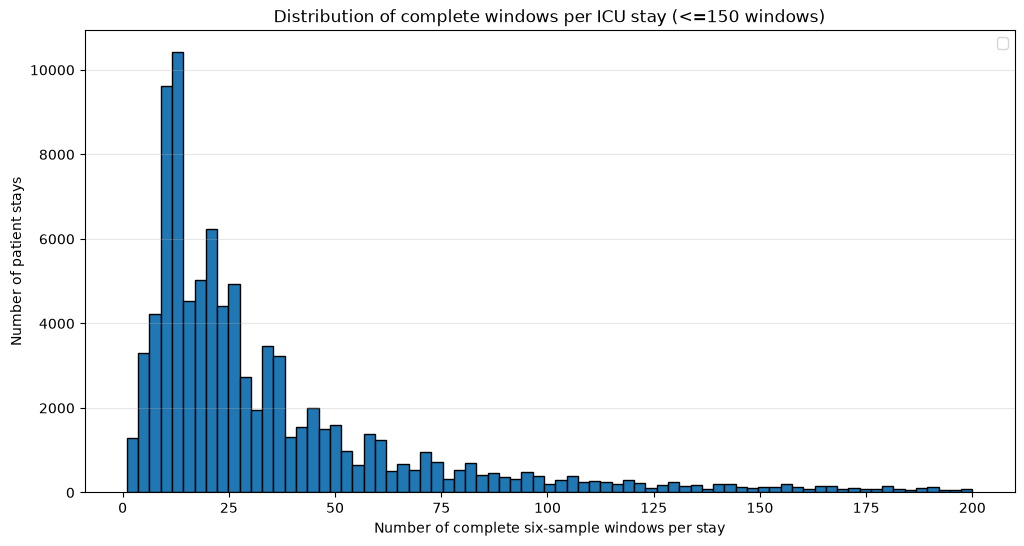

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.hist(
    window_counts[window_counts <= 200],
    bins=75,
    edgecolor="black"
)


plt.xlabel("Number of complete six-sample windows per stay")
plt.ylabel("Number of patient stays")
plt.title("Distribution of complete windows per ICU stay (<=150 windows)")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()


In [114]:
print(type(window_counts))

<class 'pandas.Series'>


In [117]:
threshold_for_personal_iso=40
personal_iso=window_counts[window_counts>=threshold_for_personal_iso].index.tolist()
global_iso=window_counts[window_counts<threshold_for_personal_iso].index.tolist()
print(len(personal_iso),len(global_iso))

27678 66051


In [119]:
example_stay_id = personal_iso[0]

feature_df.loc[
    feature_df["stay_id"] == example_stay_id,
    [
        "stay_id",
        "window_id",
        "window_position",
        "split_flag"
    ]
].describe()

,stay_id,window_id,window_position,split_flag
,,,,
count,57.0,57.000000,57.000000,57.000000
mean,30000646.0,28.000000,28.000000,0.315789
std,0.0,16.598193,16.598193,0.468961
min,30000646.0,0.000000,0.000000,0.000000
25%,30000646.0,14.000000,14.000000,0.000000
50%,30000646.0,28.000000,28.000000,0.000000
75%,30000646.0,42.000000,42.000000,1.000000
max,30000646.0,56.000000,56.000000,1.000000


In [ ]:
uniform_filtered=pd.read_parquet("uniform_filtered.parquet")

In [122]:
feature_missingness = (
    uniform_filtered[uniform_filtered.columns]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

feature_missingness.head(15)


ARTmean       95.854676
temp(F)       60.093372
temp(C)       55.533396
NBPm          35.756099
NBPd          35.694798
NBPs          35.686945
spO2           3.676877
RR             3.453025
heartrate      2.464808
time_diff      0.385745
stay_id        0.000000
window_id      0.000000
charttime      0.000000
window_uid     0.000000
dtype: float64